# Africa Credit Challenge

The goals of this `starter notebook` are:

1. How to load data into a `Pandas` dataframe

2. How to `train` a basic machine learning model

3. How to `evaluate` the model

4. How to `save` your __submission__ following the required format.

<font color="red"><b>Note: This is just a starter notebook. It is by no means an ideal solution.</b></font>

## <font color="yellow"><b>What I have done</b></font> ?
### <font color="green">1) only with feature engineering: </font>
* the F1 with logistic increased from 0.2616 to : 0.4906

These are the features :
* `loan_duration_days`: durée entre due_date et disbursement_date
* `interest_amount`: différence entre Total_Amount_to_Repay et Total_Amount
* `interest_rate`: interest_amount / Total_amount
* `lender_funding_rate`: Amount_Funded_By_Lender / Total_Amount

modified existed feature : `Total_Amount_to_Repay` = log(`Total_Amount_to_Repay`+1)

### <font color="green">2) changing the model into random forest: </font>
* The F1 from 0.4906 has became : 0.8426
### <font color="green">3) Using the StratifiedKFold: </font>
* The F1 from 0.8426 to 0.8642


### Misy comments ihany any miteny hoe teto za nicody 

de forme :

<font color="yellow">"""</font>\
Here\
<font color="yellow">"""</font>

code

<font color="yellow">"""</font>\
end\
<font color="yellow">"""</font>

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.compose import ColumnTransformer
#from sklearn.preprocessing import StandardScaler
#from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore')

## Load and Inspect the data

In [2]:
# Loading the train dataset
train = pd.read_csv('Train.csv')
test = pd.read_csv('Test.csv')
# Display the first few rows of the datasets and their shape
display("Train", train.head(), train.shape, "Test", test.head(), test.shape)

'Train'

,ID,customer_id,country_id,tbl_loan_id,lender_id,loan_type,Total_Amount,Total_Amount_to_Repay,disbursement_date,due_date,duration,New_versus_Repeat,Amount_Funded_By_Lender,Lender_portion_Funded,Lender_portion_to_be_repaid,target
0,ID_266671248032267278,266671,Kenya,248032,267278,Type_1,8448.0,8448.0,2022-08-30,2022-09-06,7,Repeat Loan,120.85,0.014305,121.0,0
1,ID_248919228515267278,248919,Kenya,228515,267278,Type_1,25895.0,25979.0,2022-07-30,2022-08-06,7,Repeat Loan,7768.50,0.300000,7794.0,0
2,ID_308486370501251804,308486,Kenya,370501,251804,Type_7,6900.0,7142.0,2024-09-06,2024-09-13,7,Repeat Loan,1380.00,0.200000,1428.0,0
3,ID_266004285009267278,266004,Kenya,285009,267278,Type_1,8958.0,9233.0,2022-10-20,2022-10-27,7,Repeat Loan,2687.40,0.300000,2770.0,0
4,ID_253803305312267278,253803,Kenya,305312,267278,Type_1,4564.0,4728.0,2022-11-28,2022-12-05,7,Repeat Loan,1369.20,0.300000,1418.0,0


(68654, 16)

'Test'

,ID,customer_id,country_id,tbl_loan_id,lender_id,loan_type,Total_Amount,Total_Amount_to_Repay,disbursement_date,due_date,duration,New_versus_Repeat,Amount_Funded_By_Lender,Lender_portion_Funded,Lender_portion_to_be_repaid
0,ID_269404226088267278,269404,Kenya,226088,267278,Type_1,1919.0,1989.0,2022-07-27,2022-08-03,7,Repeat Loan,575.7,0.300000,597.0
1,ID_255356300042267278,255356,Kenya,300042,267278,Type_1,2138.0,2153.0,2022-11-16,2022-11-23,7,Repeat Loan,0.0,0.000000,0.0
2,ID_257026243764267278,257026,Kenya,243764,267278,Type_1,8254.0,8304.0,2022-08-24,2022-08-31,7,Repeat Loan,207.0,0.025079,208.0
3,ID_264617299409267278,264617,Kenya,299409,267278,Type_1,3379.0,3379.0,2022-11-15,2022-11-22,7,Repeat Loan,1013.7,0.300000,1014.0
4,ID_247613296713267278,247613,Kenya,296713,267278,Type_1,120.0,120.0,2022-11-10,2022-11-17,7,Repeat Loan,36.0,0.300000,36.0


(18594, 15)

In [3]:
# Check column types & missing values
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68654 entries, 0 to 68653
Data columns (total 16 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           68654 non-null  object 
 1   customer_id                  68654 non-null  int64  
 2   country_id                   68654 non-null  object 
 3   tbl_loan_id                  68654 non-null  int64  
 4   lender_id                    68654 non-null  int64  
 5   loan_type                    68654 non-null  object 
 6   Total_Amount                 68654 non-null  float64
 7   Total_Amount_to_Repay        68654 non-null  float64
 8   disbursement_date            68654 non-null  object 
 9   due_date                     68654 non-null  object 
 10  duration                     68654 non-null  int64  
 11  New_versus_Repeat            68654 non-null  object 
 12  Amount_Funded_By_Lender      68654 non-null  float64
 13  Lender_portion_F

In [4]:
# Are there missing values in the train dataset ?
print(f"There are {train.isna().sum().sum()} missing values in the data.")

There are 0 missing values in the data.


### EDA

In [5]:
def plot_continuous(df, column, transform=None):
    """
    Plots visualizations for a continuous variable, showing the distribution and boxplot for both
    the original and transformed versions of the data.

    Args:
        df (pandas.DataFrame): The DataFrame containing the data.
        column (str): The column name of the continuous variable to plot.
        transform (str, optional): Transformation to apply to the data before plotting.
                                  Accepted values are 'log' or 'sqrt'. Default is None, which means no transformation.

    This function generates:
        - A histogram with a kernel density estimate (KDE) for the original data.
        - A boxplot for the original data.
        - If a transformation is specified ('log' or 'sqrt'):
            - A histogram with a KDE for the transformed data.
            - A boxplot for the transformed data.
    """
    # Create subplots for visualizations
    fig, axs = plt.subplots(2, 2, figsize=(15, 15))

    # Original data plots
    sns.histplot(df[column], kde=True, ax=axs[0, 0])
    axs[0, 0].set_title(f'Distribution of {column}')
    axs[0, 0].set_xlabel(column)

    sns.boxplot(y=df[column], ax=axs[1, 0])
    axs[1, 0].set_title(f'Box Plot of {column}')
    axs[1, 0].set_ylabel(column)

    # Transformations (log or square root)
    if transform == 'log':
        transformed_data = np.log1p(df[column])  # log1p handles log(0) gracefully
        transform_label = 'Log'
    elif transform == 'sqrt':
        transformed_data = np.sqrt(df[column])  # Square root transformation
        transform_label = 'Square Root'
    else:
        transformed_data = None  # No transformation if not specified

    # If transformed data exists, generate corresponding plots
    if transformed_data is not None:
        sns.histplot(transformed_data, kde=True, ax=axs[0, 1])
        axs[0, 1].set_title(f'{transform_label} Distribution of {column}')
        axs[0, 1].set_xlabel(f'{transform_label}({column})')

        sns.boxplot(y=transformed_data, ax=axs[1, 1])
        axs[1, 1].set_title(f'{transform_label} Box Plot of {column}')
        axs[1, 1].set_ylabel(f'{transform_label}({column})')
    else:
        # If no transformation, remove the second set of axes
        for ax in [axs[0, 1], axs[1, 1]]:
            ax.remove()

    # Adjust layout to prevent overlap
    plt.tight_layout()
    plt.show()


def plot_categorical(df, column):
    """
    Plots visualizations for a categorical variable, including a bar plot and a pie chart.

    Args:
        df (pandas.DataFrame): The DataFrame containing the data.
        column (str): The column name of the categorical variable to plot.

    This function generates:
        - A bar plot showing the counts of each category in the specified column.
        - A pie chart showing the relative proportions of each category.
    """
    # Create subplots for visualizations
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Bar plot showing counts of each category
    value_counts = df[column].value_counts()
    sns.barplot(x=value_counts.index, y=value_counts.values, ax=ax1)
    ax1.set_title(f'Bar Plot of {column}')
    ax1.set_xlabel(column)
    ax1.set_ylabel('Count')
    ax1.tick_params(axis='x', rotation=45)  # Rotate x-axis labels for better readability

    # Pie chart showing percentage distribution of each category
    ax2.pie(value_counts.values, labels=value_counts.index, autopct='%1.1f%%')
    ax2.set_title(f'Pie Chart of {column}')

    # Adjust layout to prevent overlap
    plt.tight_layout()
    plt.show()


#### Categorical exploration

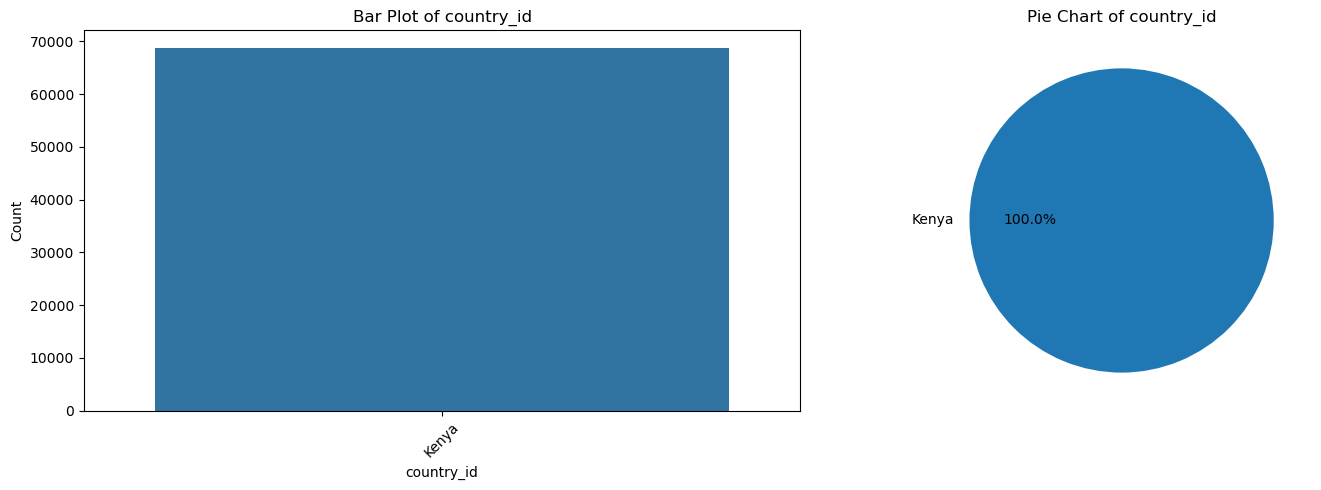

In [6]:
plot_categorical(train, 'country_id')

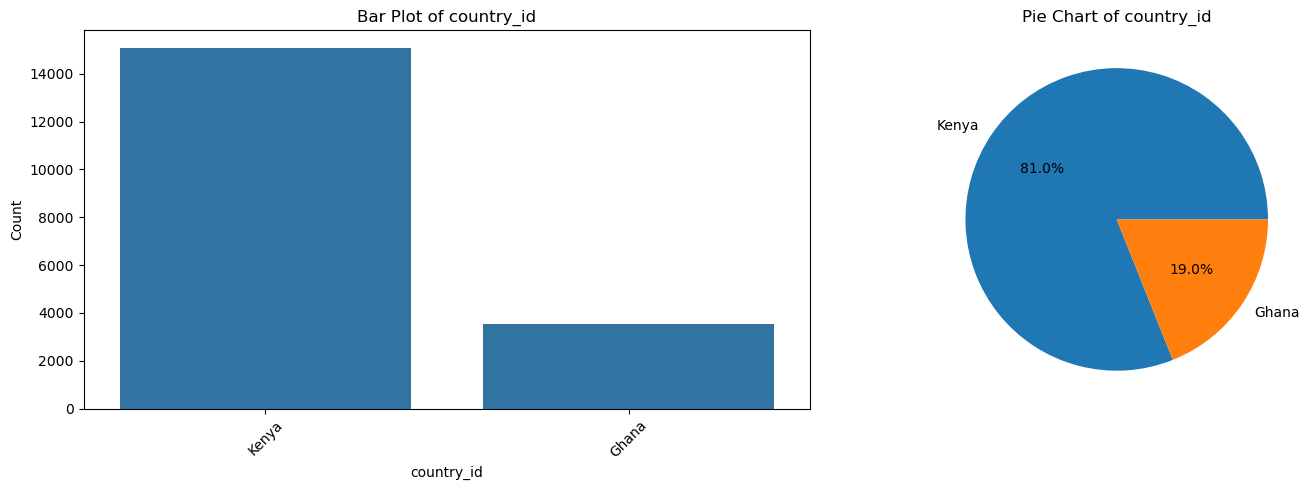

In [7]:
plot_categorical(test, 'country_id')

##### This shows that test has a new country, ghana so one of the goals is to build a solution that can generalize well in new regions

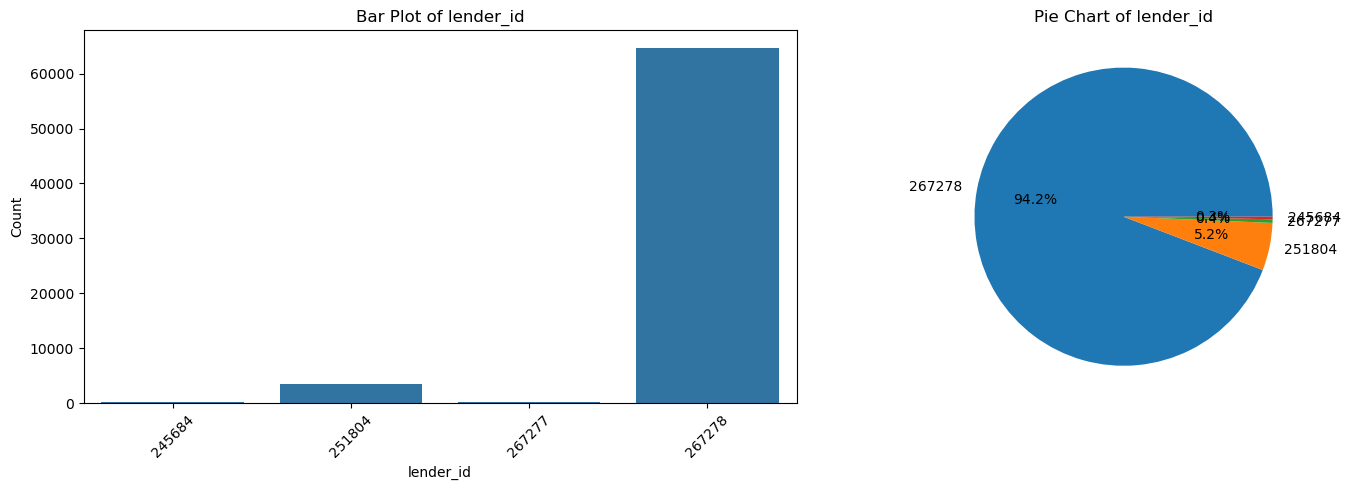

In [8]:
plot_categorical(train, 'lender_id')

##### You can exploree more of the categorical columns as well

#### TARGET EXPLORATION


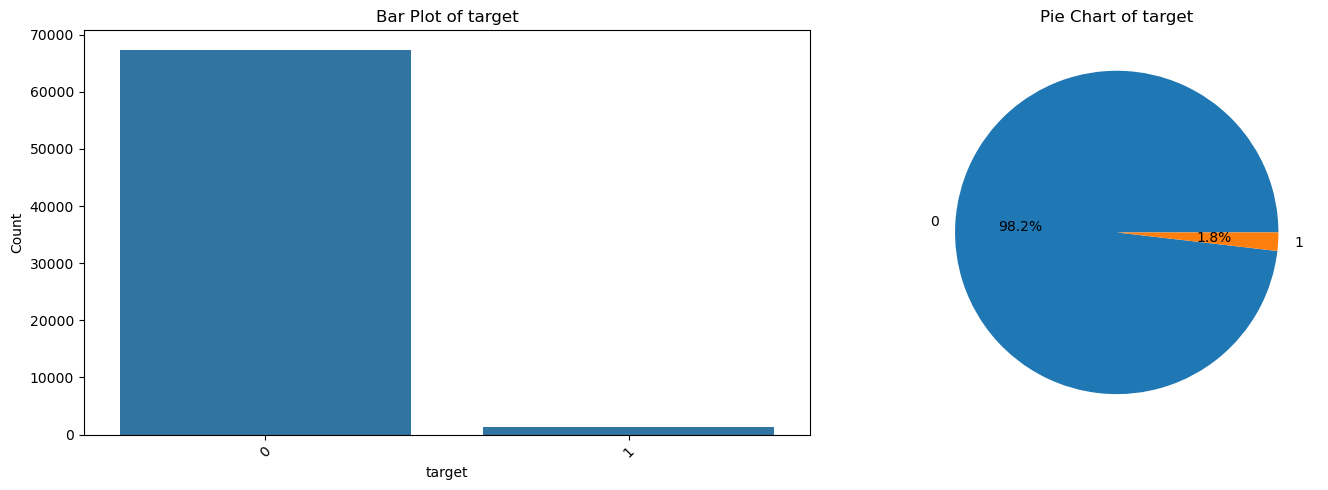

In [9]:
plot_categorical(train, 'target')

##### You can see the dataset is highly imbalanced , and this is expected in loan default scenarios, So find  ways to deal with the  imbalance

### CONTINUOUS COLUMN EXPLORATION

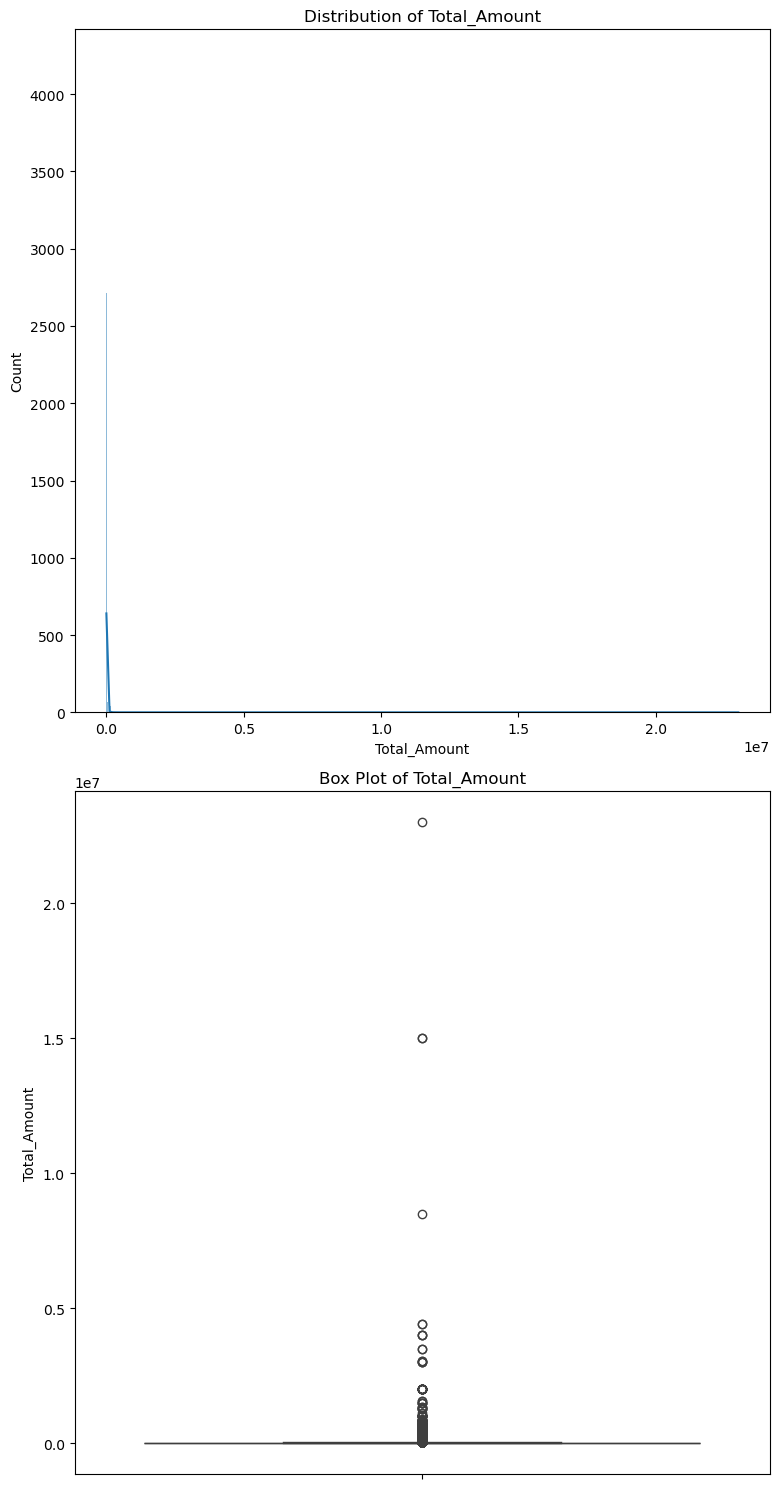

In [10]:
plot_continuous(train, 'Total_Amount')

Are those outliers?
##### You can explore more of the given numerical columns as well

### Feature Engineering
* So here we are going to concatenate both the train and test so that we can do the processing once instead of repeating for each

In [11]:
data = pd.concat([train, test]).reset_index(drop=True)

# Convert the datetime columns appropriately
date_cols = ['disbursement_date', 'due_date']
for col in date_cols:
    data[col] = pd.to_datetime(data[col])
    # Extract month, day, and year from the date columns
    data[col+'_month'] = data[col].dt.month
    data[col+'_day'] = data[col].dt.day
    data[col+'_year'] = data[col].dt.year


"""

Here:

These are the new features:
-loan_duration_days
-interest_amount
-interest_rate
-lender_funding_rate

tao ahorinan'ny fanasiana an'ireo de ni_encrease: F1 0.2616 -> 0.4906

Etsy ambany kely ilay Total_amount to log( Total_amount + 1 )
"""
data['loan_duration_days'] = (data['due_date'] - data['disbursement_date']).dt.days
data['interest_amount'] = data['Total_Amount_to_Repay'] - data['Total_Amount']
data['interest_rate'] = data['interest_amount'] / (data['Total_Amount'] + 1e-9) # +1e-9 to avoid / 0
data['lender_funding_rate'] = data['Amount_Funded_By_Lender'] / (data['Total_Amount'] + 1e-9)
"""
End
"""

# Select all categorical columns from the dataset and label encode them or one hot encode
cat_cols = data.select_dtypes(include='object').columns
num_cols = [col for col in data.select_dtypes(include='number').columns if col not in ['target']]
print(f"The categorical columns are: {cat_cols}.")
print("-"* 100)
print(f"The numerical columns are: {num_cols}")
print("-"* 100)
# we are going to one  hot encode the loan type
data = pd.get_dummies(data, columns=['loan_type'], prefix='loan_type', drop_first=False)
# Convert all the columns with prefix loan_type_ to 0/1 instead of False/True
loan_type_cols = [col for col in data.columns if col.startswith('loan_type_')]
data[loan_type_cols] = data[loan_type_cols].astype(int)

# Label-encoding for the other remaining categorical columns
le = LabelEncoder()
for col in [col for col in cat_cols if col not in ['loan_type', 'ID']]:
    data[col] = le.fit_transform(data[col])


# deal with numerical columns: we saw loan amount is  highly right skewed for this we can log transform it
data['Total_Amount'] = np.log1p(data['Total_Amount']) # study other numerical columns and see if they are skewed as well

"""
Here;
This guy, this one , ty ilay log1p aux lieu de Total_Amount tsotra
"""
data['Total_Amount_to_Repay'] = np.log1p(data['Total_Amount_to_Repay'])
"""
End
"""

# Splitting the data back into train and test
train_df = data[data['ID'].isin(train['ID'].unique())]
test_df = data[data['ID'].isin(test['ID'].unique())]


# we are also going to drop the country id as we saw we have only one country in train
features_for_modelling = [col for col in train_df.columns if col not in date_cols + ['ID', 'target', 'country_id']]

# Check if the new datasets have the same rows as train and test datasets
print(f"The shape of train_df is: {train_df.shape}")
print(f"The shape of test_df is: {test_df.shape}")
print(f"The shape of train is: {train.shape}")
print(f"The shape of test is: {test.shape}")
print(f"The features for modelling are:\n{features_for_modelling}")
print(len(features_for_modelling))


The categorical columns are: Index(['ID', 'country_id', 'loan_type', 'New_versus_Repeat'], dtype='object').
----------------------------------------------------------------------------------------------------
The numerical columns are: ['customer_id', 'tbl_loan_id', 'lender_id', 'Total_Amount', 'Total_Amount_to_Repay', 'duration', 'Amount_Funded_By_Lender', 'Lender_portion_Funded', 'Lender_portion_to_be_repaid', 'disbursement_date_month', 'disbursement_date_day', 'disbursement_date_year', 'due_date_month', 'due_date_day', 'due_date_year', 'loan_duration_days', 'interest_amount', 'interest_rate', 'lender_funding_rate']
----------------------------------------------------------------------------------------------------
The shape of train_df is: (68654, 49)
The shape of test_df is: (18594, 49)
The shape of train is: (68654, 16)
The shape of test is: (18594, 15)
The features for modelling are:
['customer_id', 'tbl_loan_id', 'lender_id', 'Total_Amount', 'Total_Amount_to_Repay', 'duration', 

### CROSS VALIDATION
* Here we are going to use a simple train test split but due to the imbalance try other robust methods like StratifiedKFold


In [12]:
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier

#X_train, X_valid, y_train, y_valid = train_test_split(train_df[features_for_modelling], train['target'], stratify=train['target'], shuffle=True, random_state=42)
#print(X_train.shape, X_valid.shape, y_train.shape, y_valid.shape)
"""
Here
"""
X = train_df[features_for_modelling]
y = train['target']
"""
end
"""

'\nend\n'

## Initialisation & Model Training

Average F1 Score: 0.8642
Average ROC AUC Score: 0.9956

Average Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     13479
           1       0.86      0.88      0.87       251

    accuracy                           1.00     13730
   macro avg       0.93      0.94      0.93     13730
weighted avg       1.00      1.00      1.00     13730



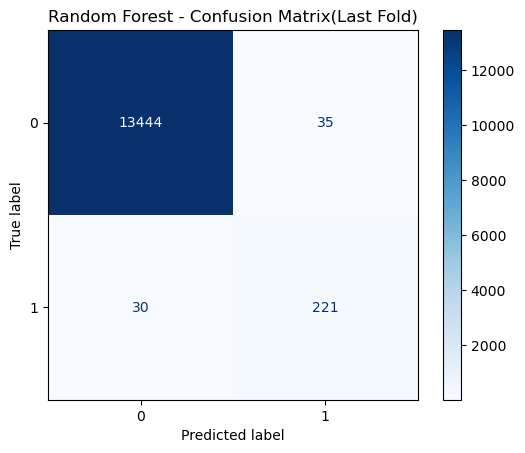

In [13]:
"""
Here:
2) changing the model into random forest:
* The F1 from 0.4906 has became : 0.8426

3) Using the StratifiedKFold increased it to : 0.8642
"""
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",  # Gérer l'imbalance
    random_state=42,
    n_jobs=-1
)

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = []
f1_scores = []
roc_auc_scores = []

for train_index, valid_index in kf.split(X, y):
    X_train_fold,X_valid_fold =X.iloc[train_index],X.iloc[valid_index]
    y_train_fold,y_valid_fold =y.iloc[train_index], y.iloc[valid_index]

    rf.fit(X_train_fold, y_train_fold)

    y_pred =rf.predict(X_valid_fold)
    y_pred_proba =rf.predict_proba(X_valid_fold)[:, 1]

    f1 = f1_score(y_valid_fold, y_pred)
    roc_auc = roc_auc_score(y_valid_fold, y_pred_proba)

    f1_scores.append(f1)
    roc_auc_scores.append(roc_auc)

print(f"Average F1 Score: {np.mean(f1_scores):.4f}")
print(f"Average ROC AUC Score: {np.mean(roc_auc_scores):.4f}")

print("\nAverage Classification Report:")
y_pred_all = rf.predict(X_valid_fold)
print(classification_report(y_valid_fold, y_pred_all))

# Afficher la matrice de confusion sur le dernier fold
ConfusionMatrixDisplay.from_predictions(
    y_valid_fold,
    y_pred_all,
    display_labels=rf.classes_,
    cmap=plt.cm.Blues
)
plt.title("Random Forest - Confusion Matrix(Last Fold)")
"""
End
"""
plt.show()


### FEATURE IMPORTANCE

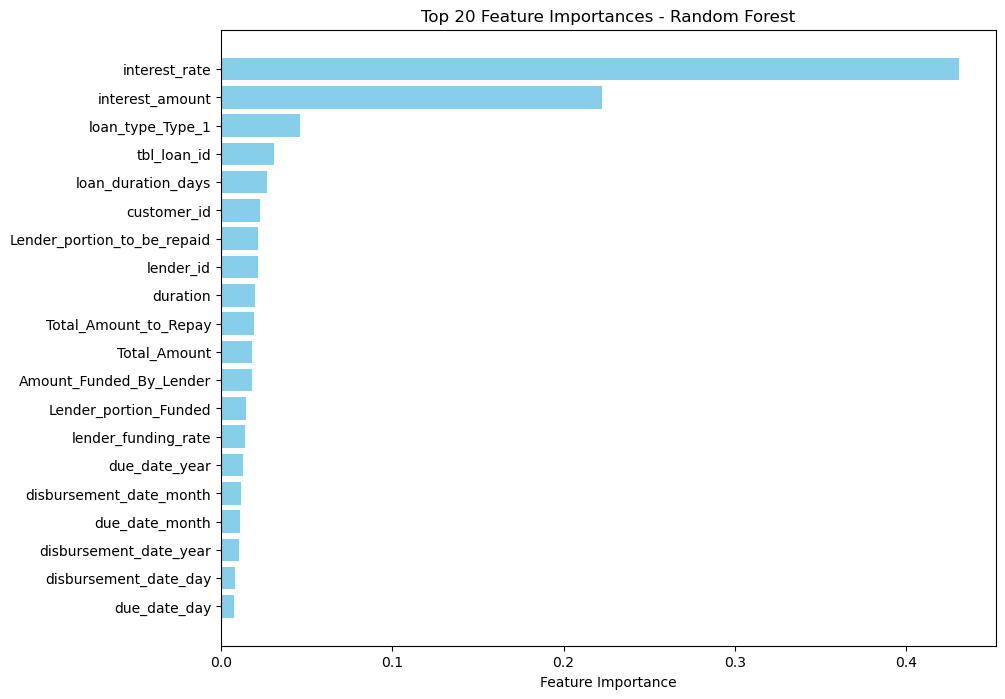

In [14]:
"""
Here
"""
feature_importances = rf.feature_importances_
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
})

importance_df = importance_df.sort_values(by='Importance', ascending=False).head(20)

# Afficher le top 20 des importances
plt.figure(figsize=(10, 8))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
plt.gca().invert_yaxis()
plt.xlabel('Feature Importance')
plt.title('Top 20 Feature Importances - Random Forest')
"""
end
"""
plt.show()


## Model Prediction & Inference

In [15]:
"""
Here
"""
test_predictions = rf.predict(test_df[features_for_modelling])
test_predictions_proba = rf.predict_proba(test_df[features_for_modelling])[:, 1]

test_df['target'] = test_predictions
sub = test_df[['ID', 'target']]
"""
end
"""
sub.head()


,ID,target
68654,ID_269404226088267278,0
68655,ID_255356300042267278,0
68656,ID_257026243764267278,0
68657,ID_264617299409267278,0
68658,ID_247613296713267278,0


In [16]:
sub.to_csv('baseline_submission.csv', index=False)

#### To Do
* Handle imbalance (have done)
* Do more feature engineering (have done)
* Use more sophisticated machine learning algorithms (have done)
##### Good luck

# All the to do were accomplished by doing These points
## <font color="yellow"><b>What I have done</b></font> ?
### <font color="green">1) only with feature engineering: </font>
* the F1 with logistic increased from 0.2616 to : 0.4906

These are the features :
* `loan_duration_days`: durée entre due_date et disbursement_date
* `interest_amount`: différence entre Total_Amount_to_Repay et Total_Amount
* `interest_rate`: interest_amount / Total_amount
* `lender_funding_rate`: Amount_Funded_By_Lender / Total_Amount

modified existed feature : `Total_Amount_to_Repay` = log(`Total_Amount_to_Repay`+1)

### <font color="green">2) changing the model into random forest: </font>
* The F1 from 0.4906 has became : 0.8426
### <font color="green">3) Using the StratifiedKFold: </font>
* The F1 from 0.8426 to 0.8642


### Misy comments ihany any miteny hoe teto za nicody 

de forme :

<font color="yellow">"""</font>\
Here\
<font color="yellow">"""</font>

code

<font color="yellow">"""</font>\
end\
<font color="yellow">"""</font>

train['target].value_counts()